In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.getcwd()

'/gpfs/home/pcg0710/RNASeq/U2OS_HP1a_AuxinHypoxia'

## Basic Sensitivity Curves of Each Treatment Relative to Control ##

In [161]:
# Importing in RNA Seq Data - TPM & DGE
TPMvals = pd.read_csv('AllSamples_TPM.csv', index_col = 1).drop('Unnamed: 0', axis = 1).head(-2)
TPMvals = TPMvals.apply(pd.to_numeric) # For filtering purposes - want to remove genes where it was 
                                       # 0.00 across all samples. Need to make numeric
DGE_Auxin_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Auxin_vs_Control.csv'), index_col=0)
DGE_Hypoxia_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Hypoxia_vs_Control.csv'), index_col=0)
DGE_AH_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_AH_vs_Control.csv'), index_col=0)

# Cleaning up Data
TPMvals = TPMvals[~TPMvals.index.str.contains('ERCC')]
TPMvals = TPMvals[(TPMvals.T != 0).any()] # Removing any genes with 0.00 across all samples

# Merging replicates
TPMmean = pd.DataFrame(index=TPMvals.index)
TPMmean['Auxin'] = TPMvals.loc[:, 'Auxin_1':'Auxin_3'].astype(float).mean(axis = 1)
TPMmean['Auxin_Hypoxia'] = TPMvals.loc[:, 'Auxin_Hypoxia_1':'Auxin_Hypoxia_3'].astype(float).mean(axis = 1)
TPMmean['Control'] = TPMvals.loc[:, 'Control_1':'Control_3'].astype(float).mean(axis = 1)
TPMmean['Hypoxia'] = TPMvals.loc[:, 'Hypoxia_1':'Hypoxia_3'].astype(float).mean(axis = 1)

# Removing any genes that are not significant or have NaN
DGE_Auxin_vs_Control = DGE_Auxin_vs_Control[~DGE_Auxin_vs_Control['padj'].isnull()]
DGE_Auxin_vs_Control = DGE_Auxin_vs_Control[DGE_Auxin_vs_Control['padj'] < 0.05]

DGE_Hypoxia_vs_Control = DGE_Hypoxia_vs_Control[~DGE_Hypoxia_vs_Control['padj'].isnull()]
DGE_Hypoxia_vs_Control = DGE_Hypoxia_vs_Control[DGE_Hypoxia_vs_Control['padj'] < 0.05]

DGE_AH_vs_Control= DGE_AH_vs_Control[~DGE_AH_vs_Control['padj'].isnull()]
DGE_AH_vs_Control = DGE_AH_vs_Control[DGE_AH_vs_Control['padj'] < 0.05]

diffexp_TPMmean_Auxin_vs_Control = TPMmean.loc[DGE_Auxin_vs_Control.index]
diffexp_TPMmean_Hypoxia_vs_Control = TPMmean.loc[DGE_Hypoxia_vs_Control.index]
diffexp_TPMmean_AH_vs_Control = TPMmean.loc[DGE_AH_vs_Control.index]

In [162]:
### Sensitivity Function ###
def calc_sensitivity(diffexp_TPMmean, treatment, control='Control', num_quantiles=20):

    # Log transform
    log_vals = np.log(diffexp_TPMmean+1)

    # Quantiles based on control expression
    quantiles = np.percentile(diffexp_TPMmean[control], np.linspace(0, 100, num_quantiles + 1))

    # Mean control expression
    mean_control = np.mean(TPMmean[control])

    # Log(E)
    LogE = np.log(quantiles[1:] / mean_control)

    # Sensitivity array
    Se = np.zeros(num_quantiles)

    # Calculate sensitivity
    for quantile in range(num_quantiles):

        q_values = log_vals[diffexp_TPMmean[control].between(quantiles[quantile], quantiles[quantile + 1],
                inclusive='neither')]

        Se[quantile] = np.mean(q_values[treatment]-q_values[control])

    return LogE, Se

### Plotting Function ###
def plot_sensitivity(LogE, Se, treatment,color):

    fig, ax = plt.subplots(figsize=(8,6))

    sns.scatterplot(x=LogE, y=Se, s=80, alpha=0.7, color=color)
    #sns.scatterplot(x=LogE2, y=Se2, s=80, alpha=0.7, color=color2)

    # Labels
    ax.set_xlabel(r"ln($\mathbf{\frac {E_{cntrl}}{\bar E_{cntrl}}}$)", fontsize=16, fontweight='bold')

    ax.set_ylabel(rf"$\mathbf{{S_e = \ln\left(\frac{{E_{{{treatment}}}}}{{E_{{Control}}}}\right)}}$",
        rotation=0, fontsize=16, fontweight='bold')

    # Axis style
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')

    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    ax.yaxis.tick_left()
    ax.xaxis.tick_bottom()
    
    ax.set_xlim([-4, 7])
    ax.set_ylim([-0.15, 0.15])

    # Label positions
    ax.xaxis.set_label_coords(0.85, 0.4)
    ax.yaxis.set_label_coords(0.8, 0.85)

    # Tick formatting
    ax.tick_params(axis='both', labelsize=14)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.show()

Auxin_logE: [-2.37228724 -1.83734273 -1.46552289 -1.14550818 -0.89959604 -0.66798039
 -0.47898191 -0.2963981  -0.13573986  0.06620604  0.23620588  0.3979658
  0.57513348  0.77062861  0.97948148  1.23964909  1.59341628  2.01033645
  2.71795078  6.11908136]
Hypoxia_logE: [-3.26169364 -2.42367877 -1.92074335 -1.52074309 -1.1609508  -0.87978166
 -0.63638277 -0.40728885 -0.18891958  0.0210846   0.21632122  0.40043212
  0.58910318  0.80096474  1.00210132  1.2671008   1.56201065  1.93142066
  2.57831614  6.11908136]
AH_logE: [-3.34976266 -2.51444099 -1.95310551 -1.52803352 -1.20318182 -0.91191157
 -0.6575784  -0.44017634 -0.2225845  -0.02196125  0.17980234  0.37717306
  0.57527058  0.78635582  0.98804667  1.24803918  1.56702699  1.94881261
  2.64444613  6.11908136]
Auxin_Se: [ 0.0081596  -0.01431115 -0.01749069 -0.00843327 -0.02034149  0.02529017
  0.0086513   0.01677947  0.00063668  0.023017    0.04430374  0.0069251
  0.0150914   0.00166635 -0.00540556 -0.02619334 -0.06304276 -0.04283565
 -0

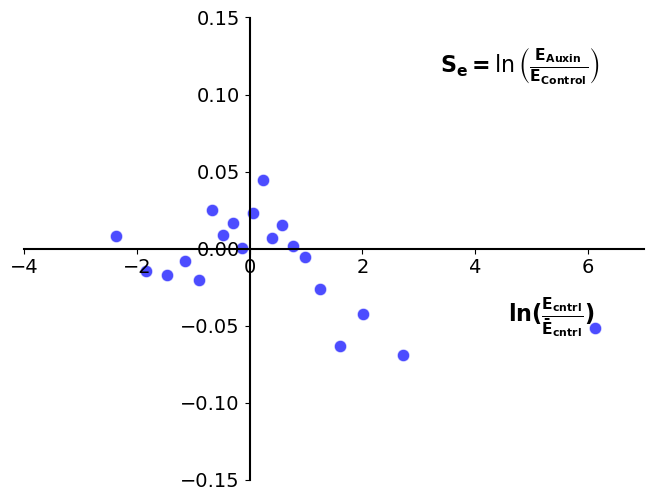

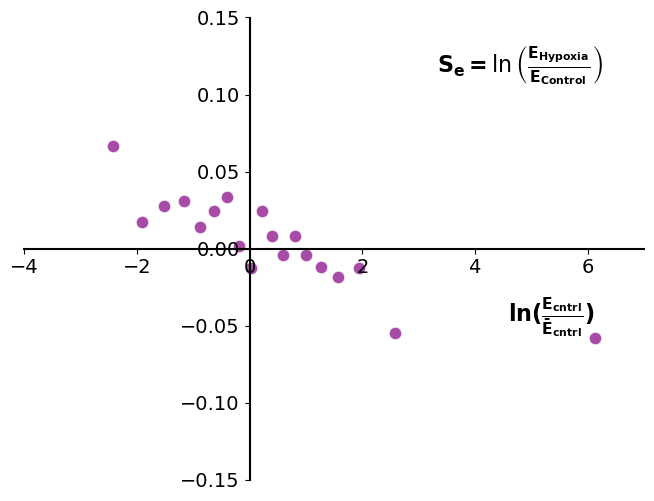

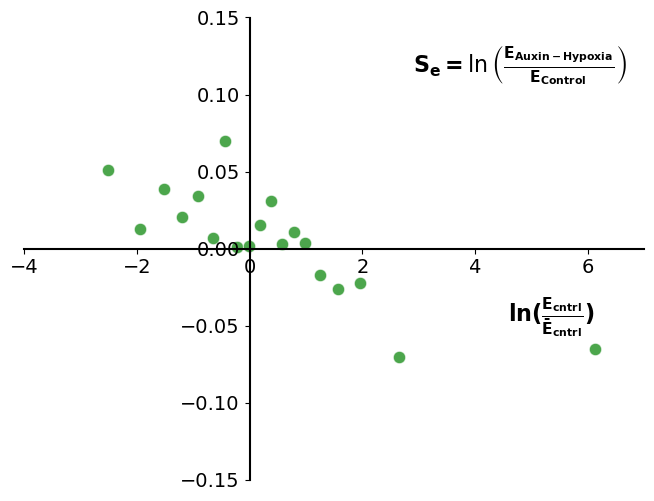

In [163]:
Auxin_logE, Auxin_Se = calc_sensitivity(diffexp_TPMmean_Auxin_vs_Control, treatment='Auxin')
Hypoxia_logE, Hypoxia_Se = calc_sensitivity(diffexp_TPMmean_Hypoxia_vs_Control, treatment='Hypoxia')
AH_logE, AH_Se = calc_sensitivity(diffexp_TPMmean_AH_vs_Control, treatment='Auxin_Hypoxia')

print('Auxin_logE:', Auxin_logE)
print('Hypoxia_logE:', Hypoxia_logE)
print('AH_logE:', AH_logE)

print('Auxin_Se:', Auxin_Se)
print('Hypoxia_Se:', Hypoxia_Se)
print('AH_Se:', AH_Se)

plot_sensitivity(Auxin_logE,Auxin_Se, treatment='Auxin',color='blue')
plot_sensitivity(Hypoxia_logE,Hypoxia_Se,treatment='Hypoxia',color='purple')
plot_sensitivity(AH_logE,AH_Se, treatment='Auxin-Hypoxia',color='green')

## Sensitivity Curves using ALL the genes - Not Filtering for Significance ##

In [164]:
# Importing in RNA Seq Data - TPM & DGE
TPMvals = pd.read_csv('AllSamples_TPM.csv', index_col = 1).drop('Unnamed: 0', axis = 1).head(-2)
TPMvals = TPMvals.apply(pd.to_numeric) # For filtering purposes - want to remove genes where it was 
                                       # 0.00 across all samples. Need to make numeric
DGE_Auxin_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Auxin_vs_Control.csv'), index_col=0)
DGE_Hypoxia_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Hypoxia_vs_Control.csv'), index_col=0)
DGE_AH_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_AH_vs_Control.csv'), index_col=0)

# Cleaning up Data
TPMvals = TPMvals[~TPMvals.index.str.contains('ERCC')]
TPMvals = TPMvals[(TPMvals.T != 0).any()] # Removing any genes with 0.00 across all samples

# Merging replicates
TPMmean = pd.DataFrame(index=TPMvals.index)
TPMmean['Auxin'] = TPMvals.loc[:, 'Auxin_1':'Auxin_3'].astype(float).mean(axis = 1)
TPMmean['Auxin_Hypoxia'] = TPMvals.loc[:, 'Auxin_Hypoxia_1':'Auxin_Hypoxia_3'].astype(float).mean(axis = 1)
TPMmean['Control'] = TPMvals.loc[:, 'Control_1':'Control_3'].astype(float).mean(axis = 1)
TPMmean['Hypoxia'] = TPMvals.loc[:, 'Hypoxia_1':'Hypoxia_3'].astype(float).mean(axis = 1)

# Removing any genes that have NaN
DGE_Auxin_vs_Control = DGE_Auxin_vs_Control[~DGE_Auxin_vs_Control['padj'].isnull()]
DGE_Hypoxia_vs_Control = DGE_Hypoxia_vs_Control[~DGE_Hypoxia_vs_Control['padj'].isnull()]
DGE_AH_vs_Control= DGE_AH_vs_Control[~DGE_AH_vs_Control['padj'].isnull()]

All_TPMmean_Auxin_vs_Control = TPMmean.loc[DGE_Auxin_vs_Control.index]
All_TPMmean_Hypoxia_vs_Control = TPMmean.loc[DGE_Hypoxia_vs_Control.index]
All_TPMmean_AH_vs_Control = TPMmean.loc[DGE_AH_vs_Control.index]

In [177]:
### Plotting Function ###
def plot_sensitivity(LogE, Se, treatment,color):

    fig, ax = plt.subplots(figsize=(8,6))

    sns.scatterplot(x=LogE, y=Se, s=80, alpha=0.7, color=color)
    #sns.scatterplot(x=LogE2, y=Se2, s=80, alpha=0.7, color=color2)

    # Labels
    ax.set_xlabel(r"ln($\mathbf{\frac {E_{cntrl}}{\bar E_{cntrl}}}$)", fontsize=16, fontweight='bold')

    ax.set_ylabel(rf"$\mathbf{{S_e = \ln\left(\frac{{E_{{{treatment}}}}}{{E_{{Control}}}}\right)}}$",
        rotation=0, fontsize=16, fontweight='bold')

    # Axis style
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')

    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    ax.yaxis.tick_left()
    ax.xaxis.tick_bottom()
    
    ax.set_xlim([-5, 7])
    ax.set_ylim([-0.10, 0.10])

    # Label positions
    ax.xaxis.set_label_coords(0.85, 0.45)
    ax.yaxis.set_label_coords(0.7, 0.80)

    # Tick formatting
    ax.tick_params(axis='both', labelsize=14)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.show()

Auxin_logE: [-3.17158327 -2.66458365 -2.293779   -1.96844096 -1.68026051 -1.38698871
 -1.1294168  -0.88321127 -0.65868101 -0.45367535 -0.24196916 -0.03878526
  0.17050441  0.37726856  0.61308925  0.85513131  1.13771154  1.52007987
  2.10694299  6.11908136]
Hypoxia_logE: [-4.29422427 -3.72590015 -3.34185748 -2.9787466  -2.63502485 -2.30551158
 -1.96312114 -1.61979417 -1.28632146 -0.97301291 -0.6928526  -0.42920731
 -0.17790357  0.07921972  0.33394471  0.62090355  0.91884917  1.32430039
  1.9245354   6.11908136]
AH_logE: [-4.67449913 -4.13425962 -3.70304202 -3.35773083 -3.00426102 -2.65068074
 -2.30369758 -1.94265467 -1.56463892 -1.22664606 -0.88665269 -0.59372887
 -0.31549672 -0.0416557   0.23837522  0.52188468  0.85401744  1.25264976
  1.87143794  6.11908136]
Auxin_Se: [ 0.04082125  0.02834312  0.01774825  0.02502626  0.02892297  0.01058136
  0.01802302  0.01430052  0.02215741  0.02773057  0.01883115  0.02418819
  0.03345123  0.01986017  0.02175239  0.01847259  0.00603288 -0.00356369
 

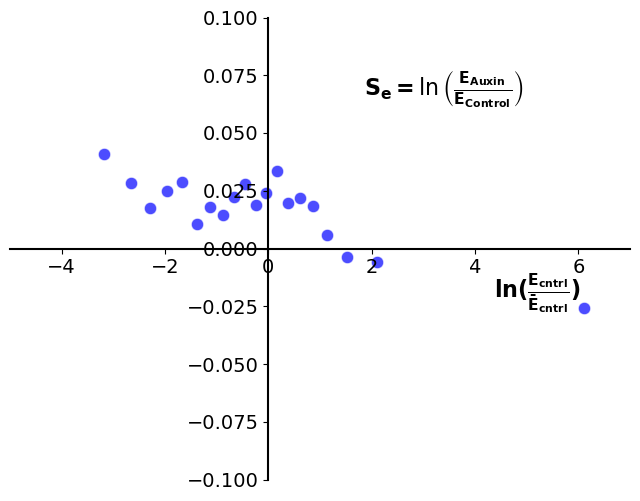

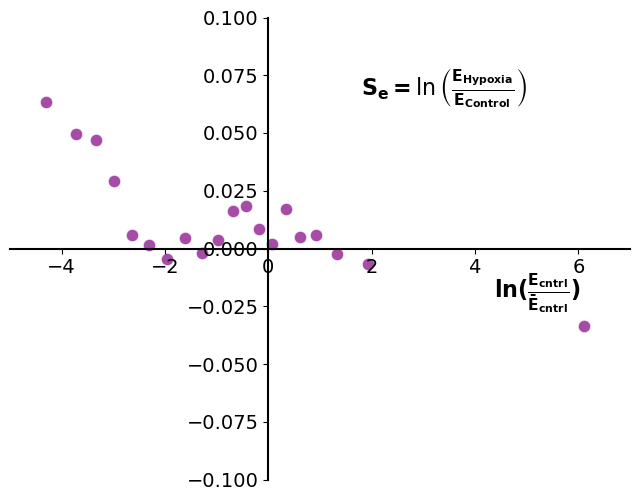

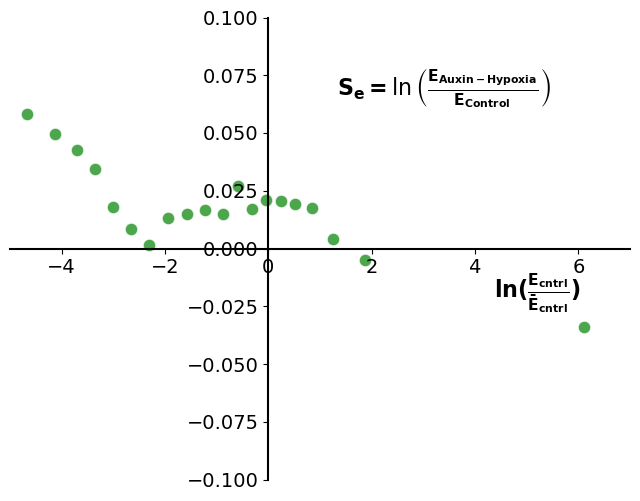

In [178]:
Auxin_logE, Auxin_Se = calc_sensitivity(All_TPMmean_Auxin_vs_Control, treatment='Auxin')
Hypoxia_logE, Hypoxia_Se = calc_sensitivity(All_TPMmean_Hypoxia_vs_Control, treatment='Hypoxia')
AH_logE, AH_Se = calc_sensitivity(All_TPMmean_AH_vs_Control, treatment='Auxin_Hypoxia')

print('Auxin_logE:', Auxin_logE)
print('Hypoxia_logE:', Hypoxia_logE)
print('AH_logE:', AH_logE)

print('Auxin_Se:', Auxin_Se)
print('Hypoxia_Se:', Hypoxia_Se)
print('AH_Se:', AH_Se)

plot_sensitivity(Auxin_logE,Auxin_Se, treatment='Auxin',color='blue')
plot_sensitivity(Hypoxia_logE,Hypoxia_Se,treatment='Hypoxia',color='purple')
plot_sensitivity(AH_logE,AH_Se, treatment='Auxin-Hypoxia',color='green')

## Now Lets Focus On Auxin-Hypoxia. Here were going to look at how significantly changed genes in the single treatment are evaluated in the combo treatment ##

In [194]:
# Importing in RNA Seq Data - TPM & DGE
TPMvals = pd.read_csv('AllSamples_TPM.csv', index_col = 1).drop('Unnamed: 0', axis = 1).head(-2)
TPMvals = TPMvals.apply(pd.to_numeric) # For filtering purposes - want to remove genes where it was 
                                       # 0.00 across all samples. Need to make numeric
DGE_Auxin_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Auxin_vs_Control.csv'), index_col=0)
DGE_Hypoxia_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Hypoxia_vs_Control.csv'), index_col=0)
DGE_AH_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_AH_vs_Control.csv'), index_col=0)

# Cleaning up Data
TPMvals = TPMvals[~TPMvals.index.str.contains('ERCC')]
TPMvals = TPMvals[(TPMvals.T != 0).any()] # Removing any genes with 0.00 across all samples

# Merging replicates
TPMmean = pd.DataFrame(index=TPMvals.index)
TPMmean['Auxin'] = TPMvals.loc[:, 'Auxin_1':'Auxin_3'].astype(float).mean(axis = 1)
TPMmean['Auxin_Hypoxia'] = TPMvals.loc[:, 'Auxin_Hypoxia_1':'Auxin_Hypoxia_3'].astype(float).mean(axis = 1)
TPMmean['Control'] = TPMvals.loc[:, 'Control_1':'Control_3'].astype(float).mean(axis = 1)
TPMmean['Hypoxia'] = TPMvals.loc[:, 'Hypoxia_1':'Hypoxia_3'].astype(float).mean(axis = 1)

# Removing any genes that are not significant or have NaN
DGE_Auxin_vs_Control = DGE_Auxin_vs_Control[~DGE_Auxin_vs_Control['padj'].isnull()]
DGE_Auxin_vs_Control = DGE_Auxin_vs_Control[DGE_Auxin_vs_Control['padj'] < 0.05]

DGE_Hypoxia_vs_Control = DGE_Hypoxia_vs_Control[~DGE_Hypoxia_vs_Control['padj'].isnull()]
DGE_Hypoxia_vs_Control = DGE_Hypoxia_vs_Control[DGE_Hypoxia_vs_Control['padj'] < 0.05]


In [195]:
# Need to create a shared set of genes -- Focusing only on Sig. Changed Genes in the single treatment conditon

#Auxin and Auxin-Hypoxia
shared_genes_Auxin_and_AH = DGE_Auxin_vs_Control.index.intersection(DGE_AH_vs_Control.index)
diffexp_TPMmean_Auxin_and_AH_shared = TPMmean.loc[shared_genes_Auxin_and_AH]

#Hypoxia and Auxin-Hypoxia
shared_genes_Hypoxia_and_AH = DGE_Hypoxia_vs_Control.index.intersection(DGE_AH_vs_Control.index)
diffexp_TPMmean_Hypoxia_and_AH_shared = TPMmean.loc[shared_genes_Hypoxia_and_AH]

#Calulating Sensitivity
Auxin_shared_logE, Auxin_shared_Se = calc_sensitivity(diffexp_TPMmean_Auxin_and_AH_shared, treatment='Auxin')
AH_shared_Auxin_logE, AH_shared_Auxin_Se = calc_sensitivity(diffexp_TPMmean_Auxin_and_AH_shared, treatment='Auxin_Hypoxia')

Hypoxia_shared_logE, Hypoxia_shared_Se = calc_sensitivity(diffexp_TPMmean_Hypoxia_and_AH_shared, treatment='Hypoxia')
AH_shared_Hypoxia_logE, AH_shared_Hypoxia_Se = calc_sensitivity(diffexp_TPMmean_Hypoxia_and_AH_shared, treatment='Auxin_Hypoxia')

# Calculating Ratios
relTransResp_Auxinsyn = Auxin_shared_Se/AH_shared_Auxin_Se
relTransResp_Hypoxsyn = Hypoxia_shared_Se/AH_shared_Hypoxia_Se

print('AH_shared_Auxin_logE:',AH_shared_Auxin_logE)
print('AH_shared_Hypoxia_logE:', AH_shared_Hypoxia_logE)

print('relTransResp_Auxinsyn:', relTransResp_Auxinsyn)
print('relTransResp_Hypoxsyn:', relTransResp_Hypoxsyn)

AH_shared_Auxin_logE: [-2.37228724 -1.83734273 -1.46552289 -1.14550818 -0.89959604 -0.66798039
 -0.47898191 -0.2963981  -0.13573986  0.06620604  0.23620588  0.3979658
  0.57513348  0.77062861  0.97948148  1.23964909  1.59341628  2.01033645
  2.71795078  6.11908136]
AH_shared_Hypoxia_logE: [-3.26169364 -2.42367877 -1.92074335 -1.52074309 -1.1609508  -0.87978166
 -0.63638277 -0.40728885 -0.18891958  0.0210846   0.21632122  0.40043212
  0.58910318  0.80096474  1.00210132  1.2671008   1.56201065  1.93142066
  2.57831614  6.11908136]
relTransResp_Auxinsyn: [ 0.27801336 -1.19364969  3.91352253 -0.37625996 -0.63352548  0.84660691
  0.28426863 -1.86618294  0.0514758   1.35334647  1.93178551  1.24279086
  2.2146402   0.11003346  0.4342853   1.44542375  3.01658261  1.21070295
  0.96747686  0.70825301]
relTransResp_Hypoxsyn: [ 1.14879822  0.92916802  1.18792951  0.74559615  0.8980149   0.62283551
  0.91635921  0.73162063  0.27610582  1.84948938  0.57644833  0.37483862
  1.91187289  0.61824268 -0.

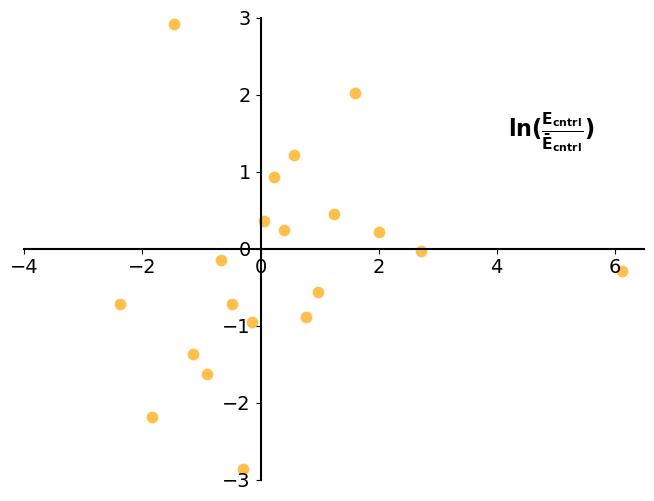

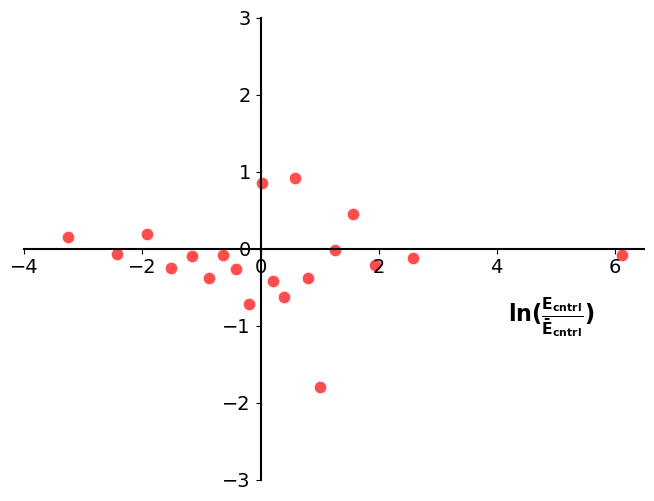

In [196]:
fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(x=AH_shared_Auxin_logE, y=relTransResp_Auxinsyn-1, s=80, alpha=0.7, color='orange')

ax.set_xlabel(r"ln($\mathbf{\frac {E_{cntrl}}{\bar E_{cntrl}}}$)", fontsize=16, fontweight='bold')
#ax.set_ylabel('Rel. Trans. Responce',rotation=0,fontsize=16, fontweight='bold' )

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.yaxis.tick_left()
ax.xaxis.tick_bottom()

ax.set_ylim([-3, 3])
#ax.set_ylim([-2, 2])
ax.set_xlim([-4,6.5])

ax.xaxis.set_label_coords(0.85, 0.8)
#ax.yaxis.set_label_coords(0.1, 0.80)

ax.tick_params(axis='both', labelsize=14)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    
fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(x=AH_shared_Hypoxia_logE, y=relTransResp_Hypoxsyn-1, s=80, alpha=0.7, color='red')

ax.set_xlabel(r"ln($\mathbf{\frac {E_{cntrl}}{\bar E_{cntrl}}}$)", fontsize=16, fontweight='bold')
#ax.set_ylabel('Rel. Trans. Responce',rotation=0,fontsize=16, fontweight='bold' )

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.yaxis.tick_left()
ax.xaxis.tick_bottom()

ax.set_ylim([-3, 3])
ax.set_xlim([-4,6.5])

ax.xaxis.set_label_coords(0.85, 0.4)
ax.yaxis.set_label_coords(0.1, 0.80)

ax.tick_params(axis='both', labelsize=14)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)   

## Now Lets Focus On Auxin-Hypoxia. Here were going to look at how significantly changed genes in the both the single and combo treament change ##

In [197]:
# Importing in RNA Seq Data - TPM & DGE
TPMvals = pd.read_csv('AllSamples_TPM.csv', index_col = 1).drop('Unnamed: 0', axis = 1).head(-2)
TPMvals = TPMvals.apply(pd.to_numeric) # For filtering purposes - want to remove genes where it was 
                                       # 0.00 across all samples. Need to make numeric
DGE_Auxin_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Auxin_vs_Control.csv'), index_col=0)
DGE_Hypoxia_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Hypoxia_vs_Control.csv'), index_col=0)
DGE_AH_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_AH_vs_Control.csv'), index_col=0)

# Cleaning up Data
TPMvals = TPMvals[~TPMvals.index.str.contains('ERCC')]
TPMvals = TPMvals[(TPMvals.T != 0).any()] # Removing any genes with 0.00 across all samples

# Merging replicates
TPMmean = pd.DataFrame(index=TPMvals.index)
TPMmean['Auxin'] = TPMvals.loc[:, 'Auxin_1':'Auxin_3'].astype(float).mean(axis = 1)
TPMmean['Auxin_Hypoxia'] = TPMvals.loc[:, 'Auxin_Hypoxia_1':'Auxin_Hypoxia_3'].astype(float).mean(axis = 1)
TPMmean['Control'] = TPMvals.loc[:, 'Control_1':'Control_3'].astype(float).mean(axis = 1)
TPMmean['Hypoxia'] = TPMvals.loc[:, 'Hypoxia_1':'Hypoxia_3'].astype(float).mean(axis = 1)

# Removing any genes that are not significant or have NaN
DGE_Auxin_vs_Control = DGE_Auxin_vs_Control[~DGE_Auxin_vs_Control['padj'].isnull()]
DGE_Auxin_vs_Control = DGE_Auxin_vs_Control[DGE_Auxin_vs_Control['padj'] < 0.05]

DGE_Hypoxia_vs_Control = DGE_Hypoxia_vs_Control[~DGE_Hypoxia_vs_Control['padj'].isnull()]
DGE_Hypoxia_vs_Control = DGE_Hypoxia_vs_Control[DGE_Hypoxia_vs_Control['padj'] < 0.05]

DGE_AH_vs_Control= DGE_AH_vs_Control[~DGE_AH_vs_Control['padj'].isnull()]
DGE_AH_vs_Control = DGE_AH_vs_Control[DGE_AH_vs_Control['padj'] < 0.05]

diffexp_TPMmean_Auxin_vs_Control = TPMmean.loc[DGE_Auxin_vs_Control.index]
diffexp_TPMmean_Hypoxia_vs_Control = TPMmean.loc[DGE_Hypoxia_vs_Control.index]
diffexp_TPMmean_AH_vs_Control = TPMmean.loc[DGE_AH_vs_Control.index]

In [198]:
# Need to create a shared set of genes
#-- Focusing only on Sig. Changed Genes in the single treatment AND the combo treatment

#Auxin and Auxin-Hypoxia
shared_genes_Auxin_and_AH = DGE_Auxin_vs_Control.index.intersection(DGE_AH_vs_Control.index)
diffexp_TPMmean_Auxin_and_AH_shared = TPMmean.loc[shared_genes_Auxin_and_AH]

#Hypoxia and Auxin-Hypoxia
shared_genes_Hypoxia_and_AH = DGE_Hypoxia_vs_Control.index.intersection(DGE_AH_vs_Control.index)
diffexp_TPMmean_Hypoxia_and_AH_shared = TPMmean.loc[shared_genes_Hypoxia_and_AH]

#Calulating Sensitivity
Auxin_shared_logE, Auxin_shared_Se = calc_sensitivity(diffexp_TPMmean_Auxin_and_AH_shared, treatment='Auxin')
AH_shared_Auxin_logE, AH_shared_Auxin_Se = calc_sensitivity(diffexp_TPMmean_Auxin_and_AH_shared, treatment='Auxin_Hypoxia')

Hypoxia_shared_logE, Hypoxia_shared_Se = calc_sensitivity(diffexp_TPMmean_Hypoxia_and_AH_shared, treatment='Hypoxia')
AH_shared_Hypoxia_logE, AH_shared_Hypoxia_Se = calc_sensitivity(diffexp_TPMmean_Hypoxia_and_AH_shared, treatment='Auxin_Hypoxia')

# Calculating Ratios
relTransResp_Auxinsyn = Auxin_shared_Se/AH_shared_Auxin_Se
relTransResp_Hypoxsyn = Hypoxia_shared_Se/AH_shared_Hypoxia_Se

print('AH_shared_Auxin_logE:',AH_shared_Auxin_logE)
print('AH_shared_Hypoxia_logE:', AH_shared_Hypoxia_logE)

print('relTransResp_Auxinsyn:', relTransResp_Auxinsyn)
print('relTransResp_Hypoxsyn:', relTransResp_Hypoxsyn)

AH_shared_Auxin_logE: [-2.10382566 -1.63925916 -1.26143217 -0.93399062 -0.65208351 -0.44125824
 -0.24670751 -0.07727084  0.12129142  0.28928442  0.46908281  0.64135022
  0.82505187  1.02729131  1.26094771  1.57746227  1.87140793  2.3790221
  3.0474249   6.11908136]
AH_shared_Hypoxia_logE: [-3.00510407 -2.19883908 -1.65509406 -1.26982521 -0.97246037 -0.72382963
 -0.47884703 -0.24521157 -0.04090105  0.15952959  0.32842492  0.51777756
  0.70758306  0.9004205   1.1118258   1.37977203  1.69511302  2.07969435
  2.72660456  6.11908136]
relTransResp_Auxinsyn: [ 0.11354906  1.07111594  4.75613849 -0.24785431  0.99855036  0.64989728
  0.1742033   8.0167789  -0.72841897  1.21722544 -0.53969273  0.81919468
  0.35396266  0.34447642  0.94598336  1.80005184  1.03703909  0.4591059
  0.76446034  0.48561581]
relTransResp_Hypoxsyn: [ 1.00496701  1.08763445  1.14498323  1.06648371  0.69646239  1.16753189
  0.85059743  0.81860289  5.01233957 -3.95130017  0.75354833  8.26461856
  0.88435364  8.64039809  0.9

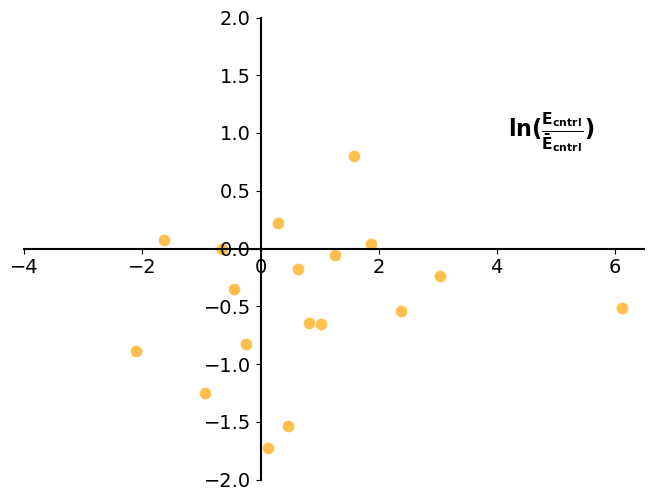

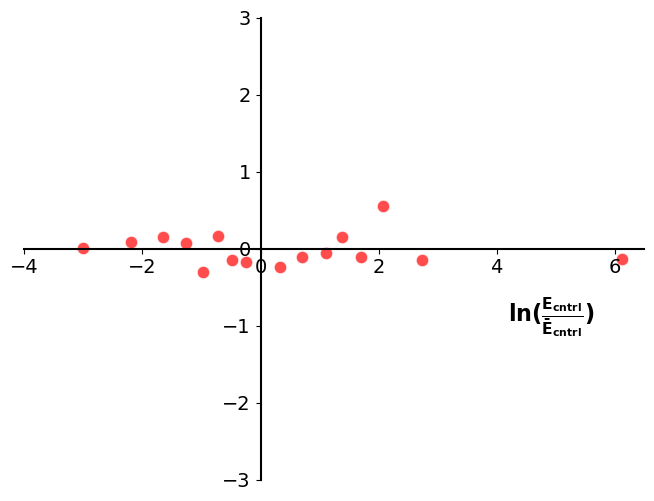

In [199]:
fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(x=AH_shared_Auxin_logE, y=relTransResp_Auxinsyn-1, s=80, alpha=0.7, color='orange')

ax.set_xlabel(r"ln($\mathbf{\frac {E_{cntrl}}{\bar E_{cntrl}}}$)", fontsize=16, fontweight='bold')
#ax.set_ylabel('Rel. Trans. Responce',rotation=0,fontsize=16, fontweight='bold' )

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.yaxis.tick_left()
ax.xaxis.tick_bottom()

#ax.set_ylim([-3, 3])
ax.set_ylim([-2, 2])
ax.set_xlim([-4,6.5])

ax.xaxis.set_label_coords(0.85, 0.8)
#ax.yaxis.set_label_coords(0.1, 0.80)

ax.tick_params(axis='both', labelsize=14)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    
fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(x=AH_shared_Hypoxia_logE, y=relTransResp_Hypoxsyn-1, s=80, alpha=0.7, color='red')

ax.set_xlabel(r"ln($\mathbf{\frac {E_{cntrl}}{\bar E_{cntrl}}}$)", fontsize=16, fontweight='bold')
#ax.set_ylabel('Rel. Trans. Responce',rotation=0,fontsize=16, fontweight='bold' )

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.yaxis.tick_left()
ax.xaxis.tick_bottom()

ax.set_ylim([-3, 3])
#ax.set_ylim([-2, 2])
ax.set_xlim([-4,6.5])

ax.xaxis.set_label_coords(0.85, 0.4)
ax.yaxis.set_label_coords(0.1, 0.80)

ax.tick_params(axis='both', labelsize=14)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)   

## Okay lets look into the specific genes now - These genes were significantly changed in BOTH single and combo treatment ## 


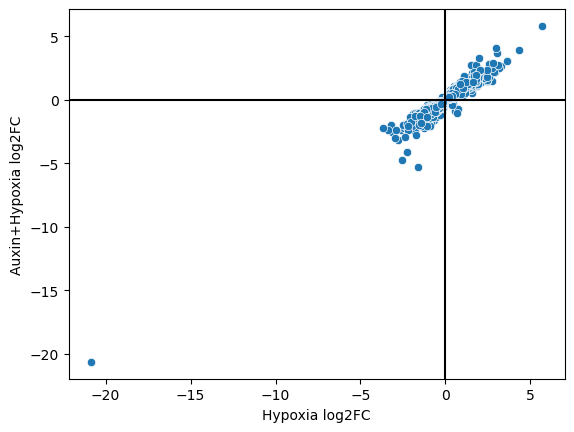

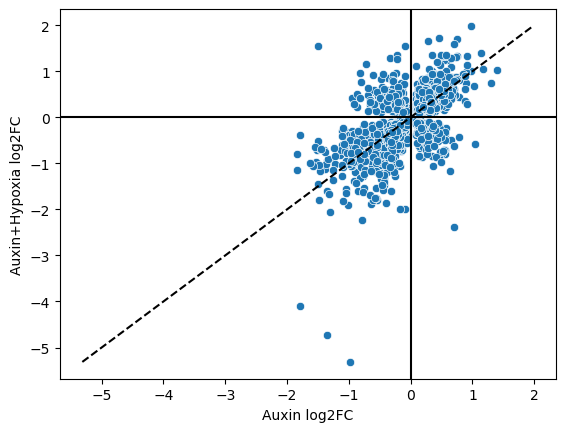

In [202]:
shared_Auxin_AH_DGE = pd.DataFrame({'Auxin_log2FC': DGE_Auxin_vs_Control.loc[shared_genes_Auxin_and_AH, 'log2FoldChange'],
                                    'AH_log2FC': DGE_AH_vs_Control.loc[shared_genes_Auxin_and_AH, 'log2FoldChange']})

shared_Hypoxia_AH_DGE = pd.DataFrame({'Hypoxia_log2FC': DGE_Hypoxia_vs_Control.loc[shared_genes_Hypoxia_and_AH, 'log2FoldChange'],
                                      'AH_log2FC': DGE_AH_vs_Control.loc[shared_genes_Hypoxia_and_AH, 'log2FoldChange']})

sns.scatterplot(data=shared_Hypoxia_AH_DGE, x='Hypoxia_log2FC', y='AH_log2FC')

ax.set_ylim([-10,7])

plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel('Hypoxia log2FC')
plt.ylabel('Auxin+Hypoxia log2FC')
plt.show()

sns.scatterplot(data=shared_Auxin_AH_DGE, x='Auxin_log2FC', y='AH_log2FC')

plt.axhline(0, color='black')
plt.axvline(0, color='black')

lims = [min(shared_Auxin_AH_DGE.min()), max(shared_Auxin_AH_DGE.max())]

plt.plot(lims, lims, 'k--')
plt.xlabel('Auxin log2FC')
plt.ylabel('Auxin+Hypoxia log2FC')
plt.show()

## Lets look at the Sensitivity Again and Plot the Combo Relative to A Single Treatment

In [203]:
# Importing in RNA Seq Data - TPM & DGE
TPMvals = pd.read_csv('AllSamples_TPM.csv', index_col = 1).drop('Unnamed: 0', axis = 1).head(-2)
TPMvals = TPMvals.apply(pd.to_numeric) # For filtering purposes - want to remove genes where it was 
                                       # 0.00 across all samples. Need to make numeric
DGE_Auxin_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Auxin_vs_Control.csv'), index_col=0)
DGE_Hypoxia_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_Hypoxia_vs_Control.csv'), index_col=0)
DGE_AH_vs_Control = pd.read_csv(os.path.join('rsem files', 'DGE_AH_vs_Control.csv'), index_col=0)

# Cleaning up Data
TPMvals = TPMvals[~TPMvals.index.str.contains('ERCC')]
TPMvals = TPMvals[(TPMvals.T != 0).any()] # Removing any genes with 0.00 across all samples

# Merging replicates
TPMmean = pd.DataFrame(index=TPMvals.index)
TPMmean['Auxin'] = TPMvals.loc[:, 'Auxin_1':'Auxin_3'].astype(float).mean(axis = 1)
TPMmean['Auxin_Hypoxia'] = TPMvals.loc[:, 'Auxin_Hypoxia_1':'Auxin_Hypoxia_3'].astype(float).mean(axis = 1)
TPMmean['Control'] = TPMvals.loc[:, 'Control_1':'Control_3'].astype(float).mean(axis = 1)
TPMmean['Hypoxia'] = TPMvals.loc[:, 'Hypoxia_1':'Hypoxia_3'].astype(float).mean(axis = 1)

# Removing any genes that are not significant or have NaN
DGE_Auxin_vs_Control = DGE_Auxin_vs_Control[~DGE_Auxin_vs_Control['padj'].isnull()]
DGE_Auxin_vs_Control = DGE_Auxin_vs_Control[DGE_Auxin_vs_Control['padj'] < 0.05]

DGE_Hypoxia_vs_Control = DGE_Hypoxia_vs_Control[~DGE_Hypoxia_vs_Control['padj'].isnull()]
DGE_Hypoxia_vs_Control = DGE_Hypoxia_vs_Control[DGE_Hypoxia_vs_Control['padj'] < 0.05]

DGE_AH_vs_Control= DGE_AH_vs_Control[~DGE_AH_vs_Control['padj'].isnull()]
DGE_AH_vs_Control = DGE_AH_vs_Control[DGE_AH_vs_Control['padj'] < 0.05]

#Auxin and Auxin-Hypoxia
shared_genes_Auxin_and_AH = DGE_Auxin_vs_Control.index.intersection(DGE_AH_vs_Control.index)
diffexp_TPMmean_Auxin_and_AH_shared = TPMmean.loc[shared_genes_Auxin_and_AH]

#Hypoxia and Auxin-Hypoxia
shared_genes_Hypoxia_and_AH = DGE_Hypoxia_vs_Control.index.intersection(DGE_AH_vs_Control.index)
diffexp_TPMmean_Hypoxia_and_AH_shared = TPMmean.loc[shared_genes_Hypoxia_and_AH]


In [210]:
def calc_combo_vs_treatment_response(diffexp_TPMmean, treatment, num_quantiles=20):

    log_vals = np.log(diffexp_TPMmean + 1)

    treatment_response = log_vals[treatment] - log_vals['Control']
    AH_response = log_vals['Auxin_Hypoxia'] - log_vals['Control']

    quantiles = np.percentile(treatment_response,np.linspace(0, 100, num_quantiles + 1))

    x_vals = np.zeros(num_quantiles)
    y_vals = np.zeros(num_quantiles)

    for q in range(num_quantiles):

        genes_in_bin = treatment_response.between(quantiles[q], quantiles[q + 1], inclusive='neither')

        x_vals[q] = np.mean(treatment_response[genes_in_bin])
        y_vals[q] = np.mean(AH_response[genes_in_bin])

    return x_vals, y_vals

HypoxiaResp_x, AH_Hypoxia_Resp_y = calc_combo_vs_treatment_response(diffexp_TPMmean_Hypoxia_and_AH_shared, 
                                                                    treatment = 'Hypoxia')
AuxinResp_x, AH_Auxin_Resp_y = calc_combo_vs_treatment_response(diffexp_TPMmean_Auxin_and_AH_shared, 
                                                                 treatment = 'Auxin')

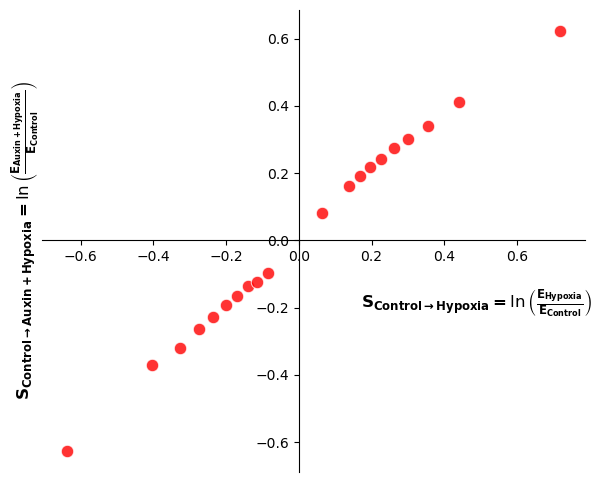

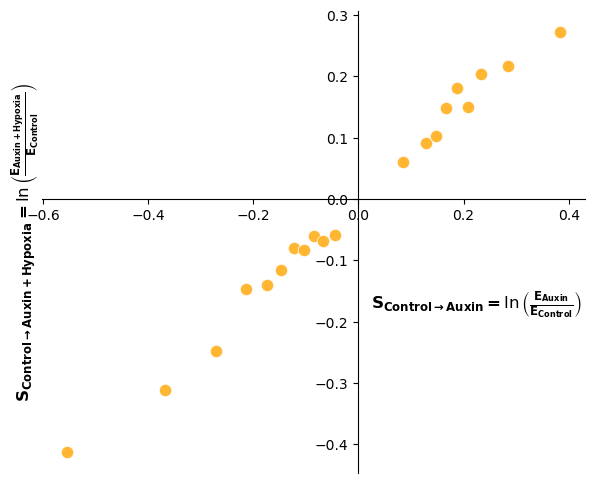

In [212]:
fig, ax = plt.subplots(figsize=(7,6))

sns.scatterplot(x=HypoxiaResp_x, y=AH_Hypoxia_Resp_y,s=80,alpha=0.8,color='red',ax=ax)

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.yaxis.tick_left()
ax.xaxis.tick_bottom()

lims = [min(HypoxiaResp_x.min(), AHResp_y.min()),max(HypoxiaResp_x.max(), AHResp_y.max())]

ax.set_xlabel(
    r"$\mathbf{S_{Control\rightarrow Hypoxia}=\ln\left(\frac{E_{Hypoxia}}{E_{Control}}\right)}$",
    fontsize=12,
    fontweight='bold')

ax.set_ylabel(
    r"$\mathbf{S_{Control\rightarrow Auxin+Hypoxia}=\ln\left(\frac{E_{Auxin+Hypoxia}}{E_{Control}}\right)}$",
    fontsize=12,
    fontweight='bold')

ax.xaxis.set_label_coords(0.8, 0.4)
ax.yaxis.set_label_coords(0, 0.5)

plt.show()

fig, ax = plt.subplots(figsize=(7,6))

sns.scatterplot(x=AuxinResp_x, y=AH_Auxin_Resp_y,s=80,alpha=0.8,color='orange',ax=ax)

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.yaxis.tick_left()
ax.xaxis.tick_bottom()

lims = [min(HypoxiaResp_x.min(), AHResp_y.min()),max(HypoxiaResp_x.max(), AHResp_y.max())]

ax.set_xlabel(
    r"$\mathbf{S_{Control\rightarrow Auxin}=\ln\left(\frac{E_{Auxin}}{E_{Control}}\right)}$",
    fontsize=12,
    fontweight='bold')

ax.set_ylabel(
    r"$\mathbf{S_{Control\rightarrow Auxin+Hypoxia}=\ln\left(\frac{E_{Auxin+Hypoxia}}{E_{Control}}\right)}$",
    fontsize=12,
    fontweight='bold')

ax.xaxis.set_label_coords(0.8, 0.4)
ax.yaxis.set_label_coords(0, 0.5)

plt.show()